# Superstore Sales Dataset Analysis

## Project Overview
This analysis explores sales data from a fictional superstore to uncover insights about:
- Sales trends over time
- Top performing products and categories
- Customer segments and profitability
- Regional performance

**Dataset Source:** Kaggle - Superstore Dataset

## Analysis Plan

**Section 1: Data Loading and Exploration** ✓
- 1.1 Import libraries
- 1.2 Load dataset
- 1.3 View basic information (shape, columns, first rows)

**Section 2: Data Cleaning and Preparation** ✓
- 2.1 Check data types
- 2.2 Check for missing values
- 2.3 Check for duplicates
- 2.4 Statistical summary

**Section 3: Exploratory Data Analysis (EDA)**
- 3.1 Sales analysis over time
- 3.2 Category and sub-category performance
- 3.3 Regional analysis
- 3.4 Customer segment analysis
- 3.5 Profitability analysis

**Section 4: Data Visualization**
- 4.1 Sales trends visualization
- 4.2 Top products/categories charts
- 4.3 Regional comparison
- 4.4 Profit vs Sales analysis

**Section 5: Key Insights and Recommendations**
- 5.1 Summary of findings
- 5.2 Business recommendations
---


## Section 1: Data Loading and Exploration

### 1.1 Import Libraries

We'll use the following Python libraries:
- **pandas**: For data manipulation and analysis
- **numpy**: For numerical operations
- **matplotlib & seaborn**: For creating visualizations

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries imported successfully!")

Libraries imported successfully!


### 1.2 Load the Dataset

When loading CSV files, we sometimes need to specify the **encoding** parameter. Encoding tells Python how to interpret the characters in the file.

**Why we use `encoding='latin-1'`:**
- Some CSV files contain special characters (like é, ñ, ™, ©)
- Different systems save files with different character encodings
- If you get a `UnicodeDecodeError`, it means Python can't read some characters with the default encoding
- `latin-1` (also called ISO-8859-1) is a common encoding that handles most special characters

**Common encodings to try:**
- `utf-8` (default, most common)
- `latin-1` or `ISO-8859-1` (for Western European characters)
- `cp1252` (Windows encoding)

In [39]:
# Load the dataset
# Note: Using encoding='latin-1' to handle special characters
df = pd.read_csv('data/Sample - Superstore.csv', encoding='latin-1')
print("Dataset loaded successfully!")

Dataset loaded successfully!


### 1.3 View Basic Information

Let's explore the basic structure of our dataset: shape, columns, and first few rows.

In [15]:
# Check the shape of the dataset (rows, columns)
print("Dataset Shape:", df.shape)
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset Shape: (9994, 21)
Rows: 9994
Columns: 21


In [18]:
# Display column names
print("Column names:")
print(df.columns.tolist())

Column names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [22]:
# View the first 3 rows
print("First 3 rows of the dataset:")
df.head(3)

First 3 rows of the dataset:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


---

## Section 2: Data Cleaning and Preparation

### 2.1 Check Data Types

Let's check what type of data each column contains.

In [32]:
# Check data types of each column
print("Data Types:")
df.dtypes

Data Types:


Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

### 2.2 Check for Missing Values

Missing data can affect our analysis, so let's check if we have any.

In [33]:
# Check for missing values
print("Missing Values:")
df.isnull().sum()

Missing Values:


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

### 2.3 Check for Duplicates

Duplicate entries can skew our analysis, so let's check if any exist.

In [36]:
# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


### 2.4 Statistical Summary

Let's examine the basic statistics of our numerical columns.

In [43]:
# Display statistical summary
print("Statistical Summary of Numerical Columns:")
df.describe()

Statistical Summary of Numerical Columns:


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


---

## Section 3: Exploratory Data Analysis (EDA)

Now let's dive into analyzing the data to uncover patterns and insights!

### 3.1 Sales Analysis Over Time

As we saw in Section 2.1, the 'Order Date' and 'Ship Date' columns are currently **object** type (text), not datetime. 

To analyze trends over time, we need to convert them to proper **datetime** format. This allows Python to understand them as dates and perform time-based operations.

In [53]:
# Convert Order Date and Ship Date to datetime format
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Ship Date']=pd.to_datetime(df['Ship Date'])
print("Date columns converted successfully!")

print("\nLet's verify the conversion:")
print(df[['Order Date', 'Ship Date']].dtypes)

Date columns converted successfully!

Let's verify the conversion:
Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


**Let's check the date range of our dataset to understand the time period covered.**

In [55]:
# Check the date range in our dataset
print("Date range in dataset:")
print(f"From: {df['Order Date'].min()}")
print(f"To: {df['Order Date'].max()}")

Date range in dataset:
From: 2014-01-03 00:00:00
To: 2017-12-30 00:00:00


**Now let's analyze total sales and profit.**

In [86]:
# Calculate total sales and profit
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Average Order Value: ${total_sales/total_orders:,.2f}")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5,009
Average Order Value: $458.61


### 3.2 Category and Sub-Category Performance

Let's see which product categories generate the most sales.

In [106]:
# Sales by Category
print("Sales by Category:")
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_sales)

Sales by Category:
Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


**Now let's look at the top performing sub-categories.**

In [108]:
# Top 10 Sub-Categories by Sales
print("Top 10 Sub-Categories by Sales:")
subcategory_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)
print(subcategory_sales)

Top 10 Sub-Categories by Sales:
Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Name: Sales, dtype: float64


### 3.3 Regional Analysis

Let's compare sales performance across different regions.

In [117]:
# Sales by Region
print("Sales by Region:")
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print(region_sales)

Sales by Region:
Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


**Let's also check profit by region to see if high sales means high profit.**

In [119]:
# Profit by Region
print("Profit by Region:")
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
print(region_profit)

Profit by Region:
Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


### 3.4 Customer Segment Analysis

Let's analyze which customer segments (Consumer, Corporate, Home Office) are most valuable.

In [138]:
segment_analysis = df.groupby('Segment').agg(
        Total_Sales=('Sales', 'sum'),
        Total_Profit=('Profit', 'sum'),
        Number_of_Orders=('Order ID', 'nunique')
        ).round(2)
print(segment_analysis)

             Total_Sales  Total_Profit  Number_of_Orders
Segment                                                 
Consumer      1161401.34     134119.21              2586
Corporate      706146.37      91979.13              1514
Home Office    429653.15      60298.68               909


### 3.5 Profitability Analysis

Let's identify the most profitable products.

In [145]:
# Top 10 Most Profitable Products
print("Top 10 Most Profitable Products:")
top_products = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)
print(top_products)

Top 10 Most Profitable Products:
Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64


**Finally, let's see which categories are most profitable.**

In [148]:
# Profit by Category
print("Profit by Category:")
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print(category_profit)

Profit by Category:
Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


---

## Section 4: Data Visualization

Visual representations help us understand patterns and communicate insights more effectively. Let's create charts for our key findings.

### 4.1 Sales Trends Over Time

Let's visualize how sales have changed over time.

In [155]:
# Extract year and month from Order Date for time series analysis
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
# Create a Year-Month column in 'YYYY-MM' format for easier grouping
# to_period('M') converts dates to monthly periods (e.g., 2016-01, 2016-02)
df['Year-Month'] = df['Order Date'].dt.to_period('M')

print("Date components extracted successfully!")

Date components extracted successfully!


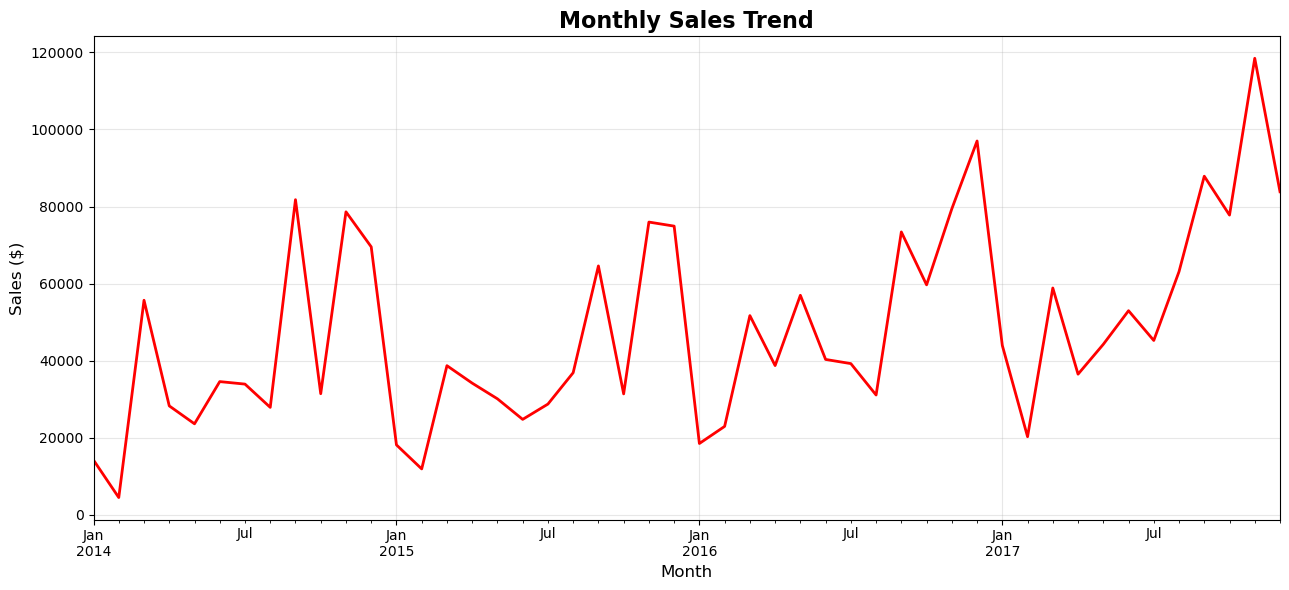

In [243]:
# Calculate monthly sales
monthly_sales = df.groupby('Year-Month')['Sales'].sum()
# Create visualization with custom styling
plt.figure(figsize=(13,6))
monthly_sales.plot(kind='line', color='red', linewidth=2)
plt.title('Monthly Sales Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Sales ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.2 Sales by Category

Let's create a bar chart to compare sales across different product categories.

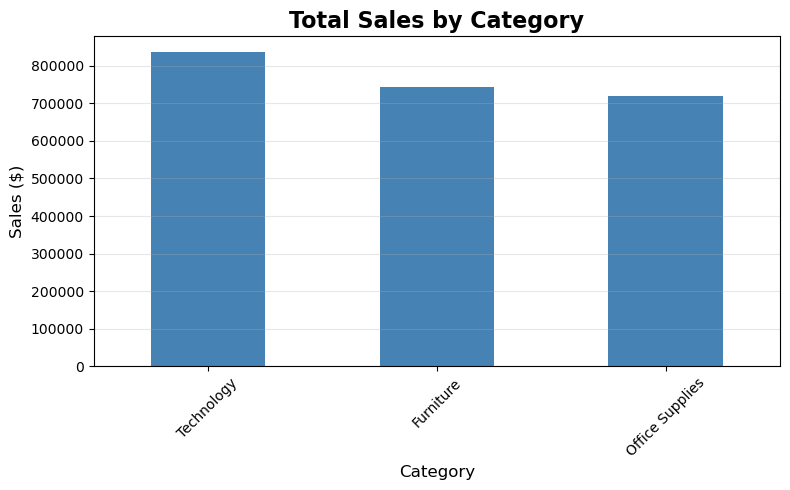

In [195]:
# Sales by Category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
# Create the plot
plt.figure(figsize=(8,5))
category_sales.plot(kind='bar',color='steelblue')
plt.title('Total Sales by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Sales ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.3 Top 10 Sub-Categories

Let's visualize the top performing sub-categories.

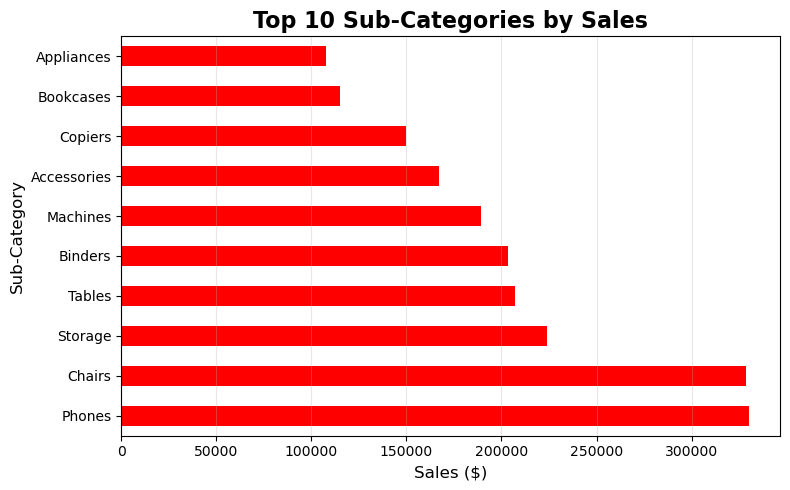

In [199]:
# Top 10 Sub-Categories by Sales
top_subcategories = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending = False).head(10)
# Create the plot
plt.figure(figsize=(8,5))
top_subcategories.plot(kind='barh', color='red')
plt.title('Top 10 Sub-Categories by Sales', fontsize=16, fontweight='bold')
plt.xlabel('Sales ($)', fontsize=12)
plt.ylabel('Sub-Category', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.4 Regional Performance

Let's compare sales across different regions.

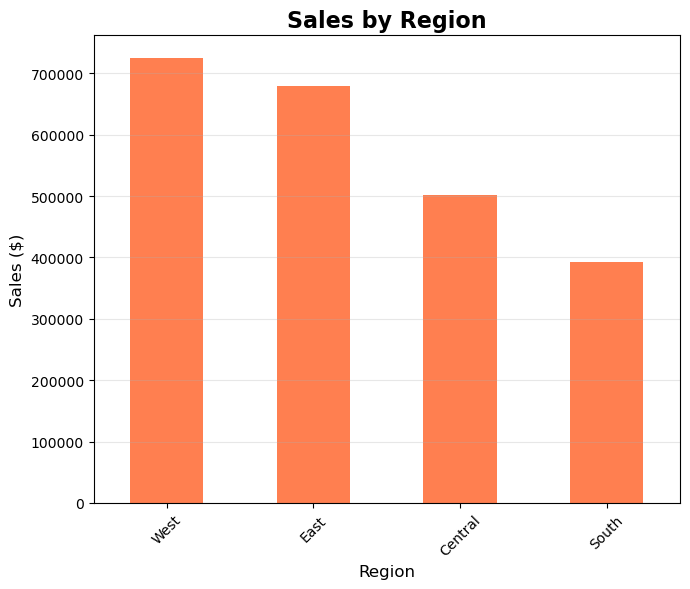

In [212]:
# Sales by Region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
# Create the plot
plt.figure(figsize=(7, 6))
region_sales.plot(kind='bar', color='coral')
plt.title('Sales by Region', fontsize=16, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Sales ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.5 Customer Segment Analysis

Let's visualize the distribution of sales across customer segments.

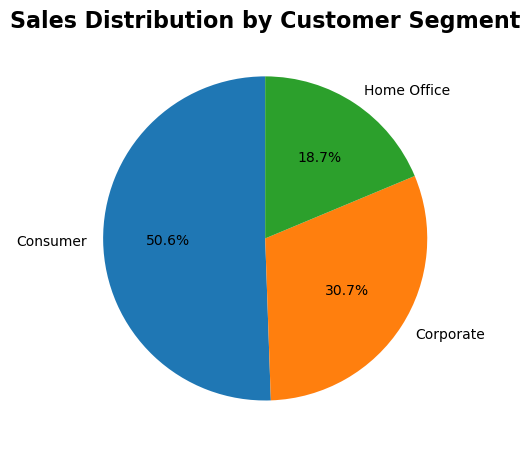

In [229]:
# Sales by Segment
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending = False)
# Create the plot
plt.figure(figsize=(5, 5))
segment_sales.plot(kind='pie',labels=segment_sales.index,autopct='%1.1f%%',startangle=90)
plt.title('Sales Distribution by Customer Segment', fontsize=16, fontweight='bold')
plt.ylabel(None)
plt.tight_layout()
plt.show()

### 4.6 Profit vs Sales Analysis

Let's examine the relationship between sales and profit.

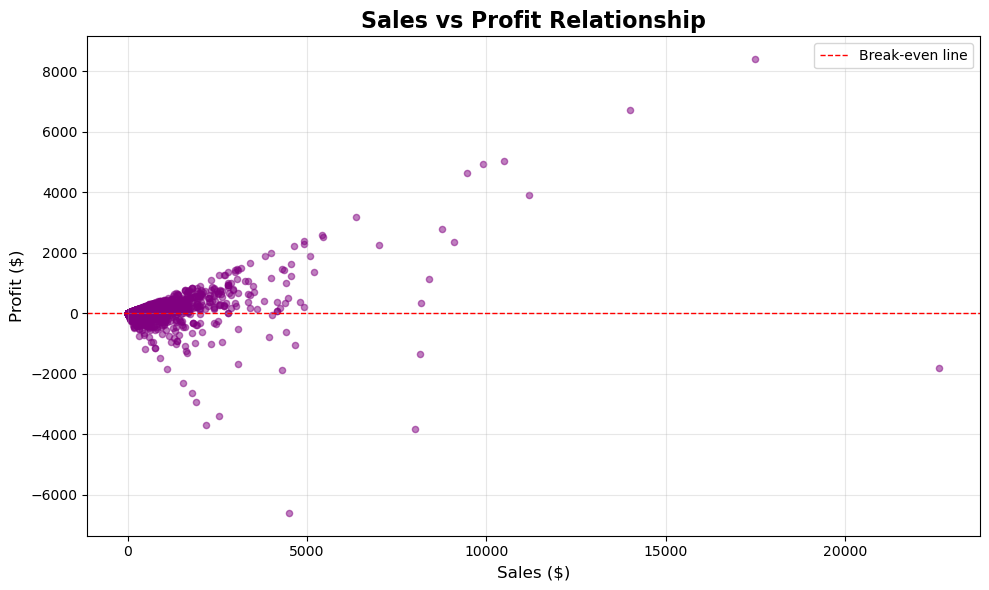

In [240]:
# Scatter plot: Sales vs Profit
df.plot(kind='scatter', x='Sales', y='Profit', alpha=0.5, color='purple',figsize=(10, 6))
plt.title('Sales vs Profit Relationship', fontsize=16, fontweight='bold')
plt.xlabel('Sales ($)', fontsize=12)
plt.ylabel('Profit ($)', fontsize=12)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1, label='Break-even line')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Section 5: Key Insights and Recommendations

### 5.1 Summary of Key Findings

Based on our analysis, here are the main insights we discovered:

**1. Sales Performance**

- The dataset contains 9,994 orders spanning from 2014 to 2017
- Total sales: \$2,297,200.86
- Total profit: \$286,397.02
- Total Orders: 5,009
- Average order value: \$458.61

**2. Category Performance**
- Technology leads in sales, followed by Furniture and Office Supplies
- Phones, Chairs, and Storage are the top-performing sub-categories
- Some products generate high sales but low profit (visible in the scatter plot)

**3. Regional Analysis**
- West region has the highest sales
- Regional performance varies - high sales doesn't always mean high profit
- All regions show positive overall performance

**4. Customer Segments**
- Consumer segment generates the most sales
- Corporate and Home Office segments also contribute significantly
- All three segments are profitable

**5. Profitability Insights**
- There's a positive correlation between sales and profit
- Some transactions show negative profit (losses) despite generating sales
- Discounting strategy may need review to improve profitability

### 5.2 Business Recommendations

Based on our findings, here are actionable recommendations:

**1. Focus on High-Performing Categories**
- Invest more in Technology products as they show strong sales performance
- Expand the product range in top sub-categories like Phones and Chairs

**2. Regional Strategy**
- Maintain strong presence in the West region
- Investigate why some regions have lower sales and develop targeted strategies

**3. Pricing and Discount Review**
- Review discount policies - some products show negative profit
- Focus on maintaining healthy profit margins while staying competitive

**4. Customer Segment Strategy**
- Continue targeting the Consumer segment as it's the largest revenue source
- Develop specialized offerings for Corporate and Home Office segments

**5. Product Mix Optimization**
- Identify and reduce inventory of low-profit products
- Promote high-margin products more aggressively